<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPLORATORY DATA ANALYSIS

Shape of dataset: (150, 5)

Data types:
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Missing values per column:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class distribution (Species):
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Summary statistics:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  Pe

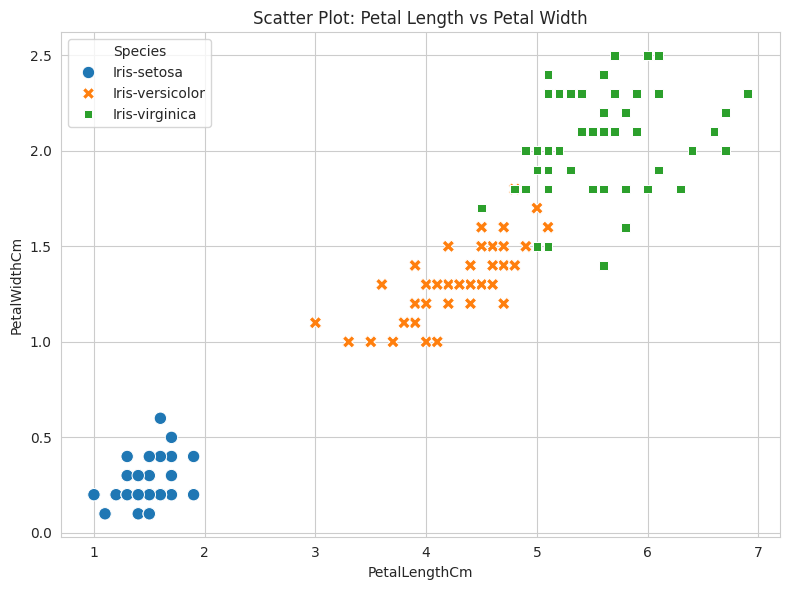

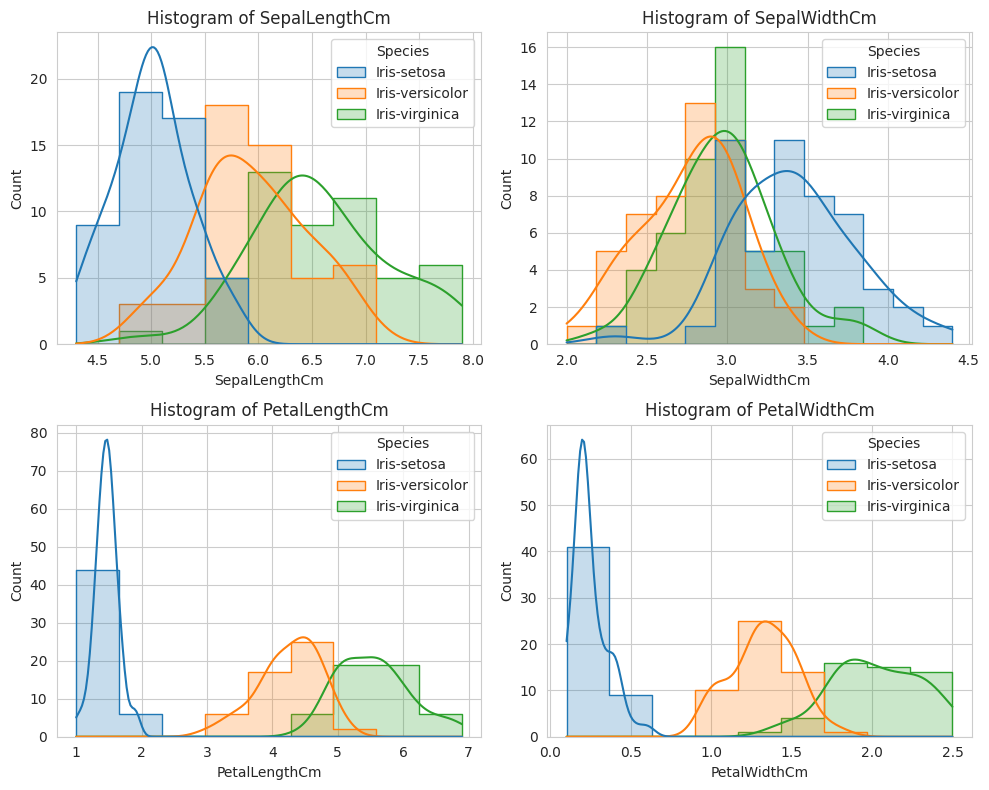

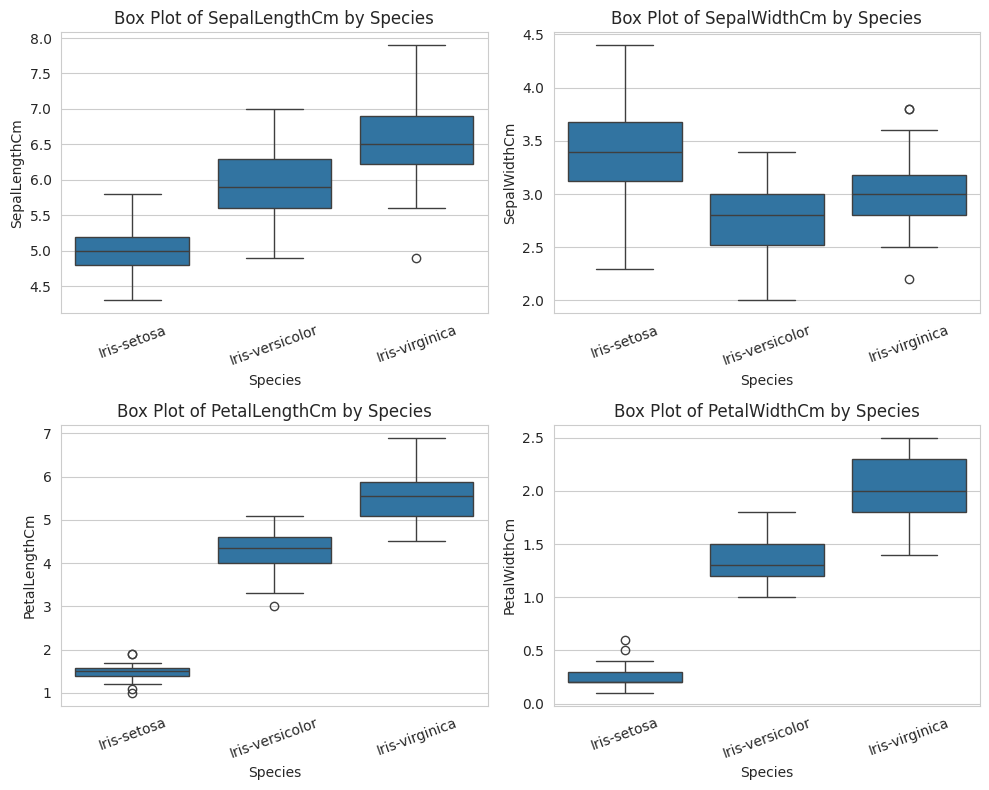

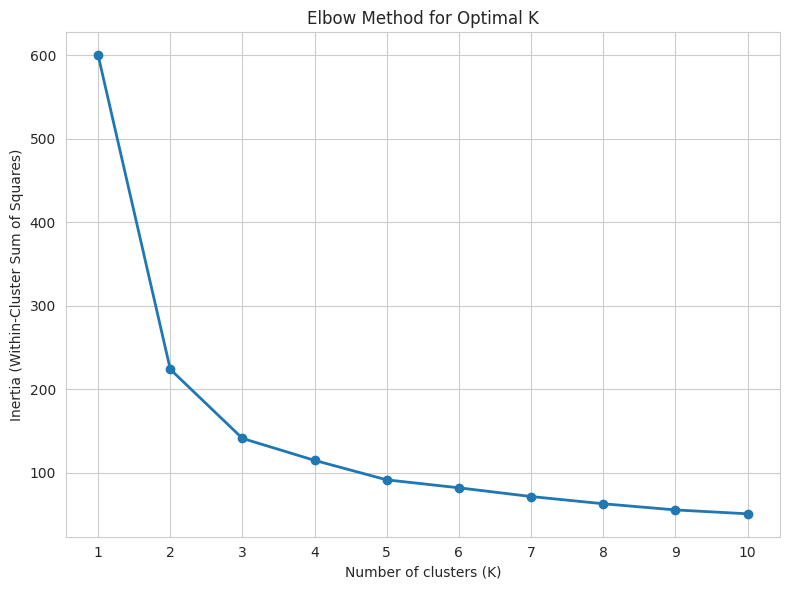


K-MEANS: Inertia for each K
K=1: inertia=600.00
K=2: inertia=223.73
K=3: inertia=140.97
K=4: inertia=114.62
K=5: inertia=91.30
K=6: inertia=81.76
K=7: inertia=71.32
K=8: inertia=62.65
K=9: inertia=55.26
K=10: inertia=50.62

Cluster sizes for K=3:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster vs actual Species crosstab (K=3):
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               39              14
1                 50                0               0
2                  0               11              36


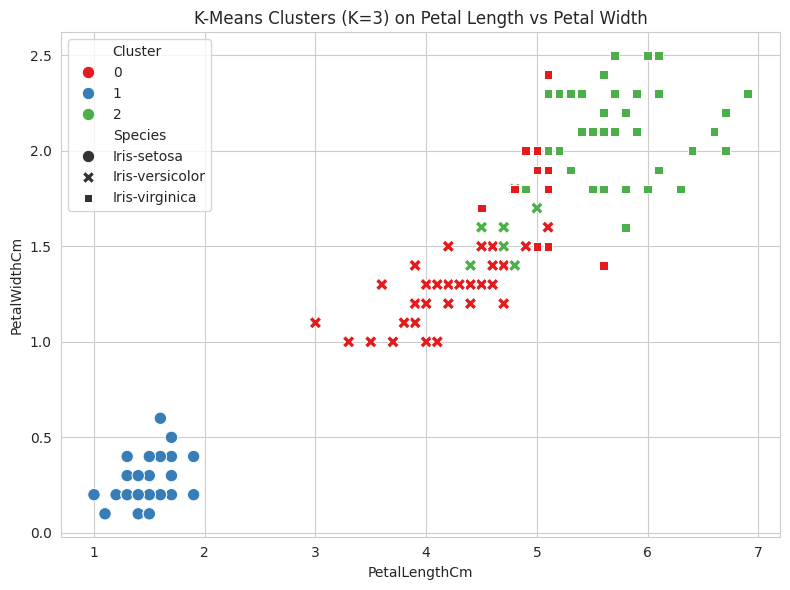


All plots saved: 1_scatter_plot.png, 1b_scatter_matrix.png, 2_histogram.png, 3_box_plot.png, 4_elbow_plot.png, 5_kmeans_clusters.png


In [2]:
'''Program 17: Dataset: Iris.csv
a) Conduct exploratory data analysis on the given dataset and report the details.
b) Visualize the analysis results using (i) scatter plot (ii) histogram & (iii) box plot.
c) Implement the K-Means clustering algorithm using the dataset. Try with different K values and plot the elbow graph for the k values.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# Load data
df = pd.read_csv("/content/Iris.csv")
if "Id" in df.columns:
    df = df.drop(columns=["Id"])

feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]


# (a) EXPLORATORY DATA ANALYSIS
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print(f"\nShape of dataset: {df.shape}")

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nClass distribution (Species):")
print(df["Species"].value_counts())

print("\nSummary statistics:")
print(df[feature_cols].describe())

print("\nCorrelation matrix:")
corr = df[feature_cols].corr()
print(corr)

print("\nSkewness of each feature:")
print(df[feature_cols].skew())


# (b) VISUALIZATIONS
# ---- (i) Scatter plot ----
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="PetalLengthCm", y="PetalWidthCm",
    hue="Species", style="Species", s=80
)
plt.title("Scatter Plot: Petal Length vs Petal Width")
plt.tight_layout()
plt.savefig("1_scatter_plot.png", dpi=200)
plt.show()

# ---- (ii) Histogram ----
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.histplot(data=df, x=col, hue="Species", kde=True, ax=ax, element="step")
    ax.set_title(f"Histogram of {col}")
plt.tight_layout()
plt.savefig("2_histogram.png", dpi=200)
plt.show()

# ---- (iii) Box plot ----
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x="Species", y=col, ax=ax)
    ax.set_title(f"Box Plot of {col} by Species")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("3_box_plot.png", dpi=200)
plt.show()


# (c) K-MEANS CLUSTERING + ELBOW METHOD
X = df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Elbow plot
plt.figure(figsize=(8, 6))
plt.plot(list(k_range), inertias, marker="o", linewidth=2)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig("4_elbow_plot.png", dpi=200)
plt.show()

print("\n" + "=" * 60)
print("K-MEANS: Inertia for each K")
print("=" * 60)
for k, inertia in zip(k_range, inertias):
    print(f"K={k}: inertia={inertia:.2f}")

# Fit final model at K=3 (matches the 3 known Iris species; also the elbow)
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df["Cluster"] = cluster_labels

print(f"\nCluster sizes for K={final_k}:")
print(df["Cluster"].value_counts().sort_index())

print(f"\nCluster vs actual Species crosstab (K={final_k}):")
print(pd.crosstab(df["Cluster"], df["Species"]))

# Visualize the final clusters on Petal Length vs Petal Width
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="PetalLengthCm", y="PetalWidthCm",
    hue="Cluster", palette="Set1", style="Species", s=80
)
plt.title(f"K-Means Clusters (K={final_k}) on Petal Length vs Petal Width")
plt.tight_layout()
plt.savefig("5_kmeans_clusters.png", dpi=200)
plt.show()

print("\nAll plots saved: 1_scatter_plot.png, 1b_scatter_matrix.png, "
      "2_histogram.png, 3_box_plot.png, 4_elbow_plot.png, 5_kmeans_clusters.png")